# Experiment 4 : Spatial Signaling and Proliferation

**Drug Modeled:** Gefitinib

**Condition Tested:** EGFR signaling and proliferation rates in a drug gradient

**Research Question:** How do spatial drug gradients create biological response gradients?

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Tissue depth range (cm)
L = 0.2
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Diffusion simulation time (s)
T_diffusion = 3600
nt = 5000

dt = T_diffusion / nt

# Layer boundaries (cm)
boundary_1 = 0.05
boundary_2 = 0.12

# Diffusion coefficients (cm^2/s)
D1 = 5e-7
D2 = 1e-7
D3 = 5e-7

# Spatial diffusivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Initial concentration
C = np.zeros(nx)

C[0] = C_source

# Save concentration profiles over time
save_every = 25
saved_profiles = []

In [32]:
# Diffusion simulation
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Constant source boundary
    C[0] = C_source

    if t % save_every == 0:
        saved_profiles.append(C.copy())

# Final spatial gefitinib concentration
G = C.copy()

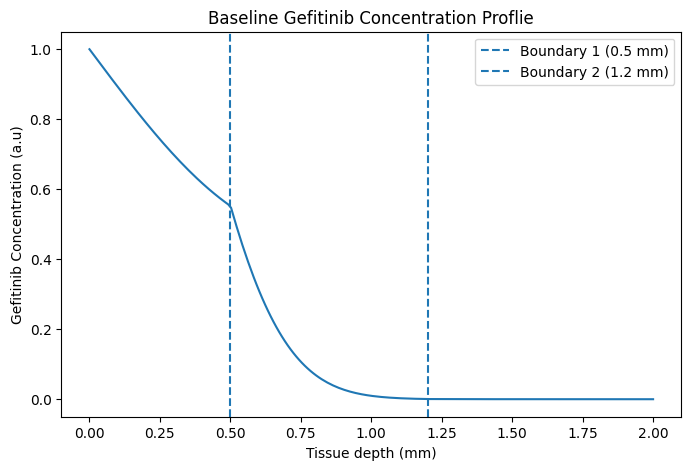

In [33]:
# Plot
plt.figure(figsize=(8, 5))

plt.plot(x * 10, G)

plt.title("Baseline Gefitinib Concentration Proflie")
plt.xlabel("Tissue depth (mm)")
plt.ylabel("Gefitinib Concentration (a.u)")

plt.axvline(boundary_1 * 10, linestyle="--", label="Boundary 1 (0.5 mm)")
plt.axvline(boundary_2 * 10, linestyle="--", label="Boundary 2 (1.2 mm)")

plt.savefig("figures/exp04b-A-baseline_gefit")
plt.legend()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Parameter dictionary
params = {
    "EGF" : 1.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

species = [
    "EGFR*",
    "RAS*",
    "RAF*",
    "MEK*",
    "ERK*",
    "Cyclin D",
    "P"
]

# Final solution array
solutions_final = np.zeros((7, nx))

# Steady-state run time
T_steady = 80
T_eval = np.linspace(0, T_steady, 500)

# ODE function definition
def pathway(t, y, params, G_x):
    # External factors
    EGF = params["EGF"]
    G = G_x
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]

In [35]:
i = 100
G_local = G[i]

solution = solve_ivp(
    pathway,
    [0, T_steady],
    y0,
    args=(params, G_local),
    t_eval=T_eval
)

print(solution.success)
print(solution.y[:, -1])

True
[0.65987799 0.56902481 0.53215373 0.51572759 0.50757758 1.01549503
 2.03063074]
